# Step 3: EEGNet Baseline

**Goal:** implement EEGNet, verify the implementation is correct, and get first classification results on the preprocessed BCI IV-2a data.

**Contents**
1. Our EEGNet implementation (PyTorch, following Lawhern et al., 2018)
2. Correctness checks, including a comparison against the reference implementation in the `braindecode` library
3. Within-subject results for all 9 subjects (our EEGNet vs braindecode's EEGNet)
4. Preliminary **cross-subject** results (leave-one-subject-out), the actual setting of our project

In [1]:
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")   # silence braindecode/MNE deprecation warnings in the output
sys.path.insert(0, str(Path.cwd().parent / "src"))
from braindecode.models import EEGNet as BraindecodeEEGNet
from data import CLASS_NAMES, SUBJECTS
from models import EEGNet
from plots import per_class_recall, plot_confusion_grid, plot_curves_grid, plot_recall_heatmap
from preprocess import load_processed
from train import DEVICE, ChannelScaler, classification_metrics, predict_logits, set_seed, train_model

RESULTS = Path.cwd().parent / "results"
FIG_DIR = RESULTS / "figures"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print(f"PyTorch {torch.__version__}, device: {DEVICE}"
      + (f" ({torch.cuda.get_device_name(0)})" if DEVICE.type == "cuda" else ""))

PyTorch 2.14.0+cu126, device: cuda (NVIDIA GeForce RTX 4060 Laptop GPU)


## 1. Our EEGNet implementation

Code: `src/models.py`. The architecture follows Lawhern et al. (2018). The paper's kernel sizes were defined at 128 Hz, so we scale them to our 250 Hz using the paper's own rules:

| Setting | Paper (128 Hz) | Ours (250 Hz) | Rule |
|---|---|---|---|
| Temporal kernel | 64 | **125** | half the sampling rate (0.5 s) |
| Separable kernel | 16 | **31** | 0.5 s after the first pooling |
| F1 / D / F2 | 8 / 2 / 16 | 8 / 2 / 16 | same |
| Pooling | 4, 8 | 4, 8 | same |
| Max-norm | 1.0 (spatial), 0.25 (dense) | same | same |
| Dropout | 0.5 within-subject, 0.25 cross-subject | same | same |

Below, a single trial is passed through the network and the output shape of each layer is printed.

In [2]:
model = EEGNet()
shapes = []
hooks = [m.register_forward_hook(lambda mod, i, o, n=n: shapes.append((n, type(mod).__name__, tuple(o.shape))))
         for n, m in model.named_children()]
model.eval()
with torch.no_grad():
    model(torch.randn(1, 22, 1000))
for h in hooks:
    h.remove()

params = {n: sum(p.numel() for p in m.parameters()) for n, m in model.named_children()}
layer_table = pd.DataFrame([(n, t, s, params[n]) for n, t, s in shapes],
                           columns=["layer", "type", "output shape (batch, filters, H, W)", "parameters"])
print(f"Input: (1, 22, 1000) = one trial of 22 channels x 1000 samples")
print(f"Total trainable parameters: {sum(p.numel() for p in model.parameters()):,}")
layer_table

Input: (1, 22, 1000) = one trial of 22 channels x 1000 samples
Total trainable parameters: 4,172


,layer,type,"output shape (batch, filters, H, W)",parameters
0,conv_temporal,Conv2d,"(1, 8, 22, 1000)",1000
1,bn1,BatchNorm2d,"(1, 8, 22, 1000)",16
2,conv_spatial,Conv2d,"(1, 16, 1, 1000)",352
3,bn2,BatchNorm2d,"(1, 16, 1, 1000)",32
4,elu,ELU,"(1, 16, 1, 1000)",0
5,pool1,AvgPool2d,"(1, 16, 1, 250)",0
6,drop1,Dropout,"(1, 16, 1, 250)",0
7,conv_separable_depth,Conv2d,"(1, 16, 1, 250)",496
8,conv_separable_point,Conv2d,"(1, 16, 1, 250)",256
9,bn3,BatchNorm2d,"(1, 16, 1, 250)",32


## 2. Correctness checks

### 2a. Same architecture as braindecode's EEGNet
`braindecode` is a widely used open-source deep-learning library for EEG. Junqueira et al. (2024) used its EEGNet. We build it with the same settings and compare every layer.

In [3]:
def make_braindecode_eegnet(dropout):
    return BraindecodeEEGNet(n_chans=22, n_outputs=4, n_times=1000, kernel_length=125,
                             depthwise_kernel_length=31, drop_prob=dropout,
                             final_layer_with_constraint=True).cpu()

LAYER_MAP = [("conv_temporal", "conv_temporal"), ("bn1", "bnorm_temporal"), ("conv_spatial", "conv_spatial"),
             ("bn2", "bnorm_1"), ("conv_separable_depth", "conv_separable_depth"),
             ("conv_separable_point", "conv_separable_point"), ("bn3", "bnorm_2"),
             ("classifier", "final_layer.linearconstraint")]

ours, ref = EEGNet(dropout=0.25), make_braindecode_eegnet(0.25)
rows = []
for o, b in LAYER_MAP:
    mo, mb = ours.get_submodule(o), ref.get_submodule(b)
    rows.append({"our layer": o, "braindecode layer": b,
                 "our weight shape": tuple(mo.weight.shape), "braindecode weight shape": tuple(mb.weight.shape),
                 "our params": sum(p.numel() for p in mo.parameters()),
                 "braindecode params": sum(p.numel() for p in mb.parameters())})
arch = pd.DataFrame(rows)
arch["match"] = (arch["our weight shape"] == arch["braindecode weight shape"]) & (arch["our params"] == arch["braindecode params"])
total_ours = sum(p.numel() for p in ours.parameters())
total_ref = sum(p.numel() for p in ref.parameters())
print(f"Total parameters: ours = {total_ours:,}, braindecode = {total_ref:,}; all layers match: {arch['match'].all()}")
assert arch["match"].all() and total_ours == total_ref
arch

Total parameters: ours = 4,172, braindecode = 4,172; all layers match: True


,our layer,braindecode layer,our weight shape,braindecode weight shape,our params,braindecode params,match
0,conv_temporal,conv_temporal,"(8, 1, 1, 125)","(8, 1, 1, 125)",1000,1000,True
1,bn1,bnorm_temporal,"(8,)","(8,)",16,16,True
2,conv_spatial,conv_spatial,"(16, 1, 22, 1)","(16, 1, 22, 1)",352,352,True
3,bn2,bnorm_1,"(16,)","(16,)",32,32,True
4,conv_separable_depth,conv_separable_depth,"(16, 1, 1, 31)","(16, 1, 1, 31)",496,496,True
5,conv_separable_point,conv_separable_point,"(16, 16, 1, 1)","(16, 16, 1, 1)",256,256,True
6,bn3,bnorm_2,"(16,)","(16,)",32,32,True
7,classifier,final_layer.linearconstraint,"(4, 496)","(4, 496)",1988,1988,True


### 2b. Same computation (numerical equivalence)
Matching shapes are not enough: the layers must also be wired identically (grouped convolutions, pooling, flatten order). We copy braindecode's weights into our model, randomize the BatchNorm statistics so every layer matters, and feed both networks the same random inputs. **The outputs must be identical.**

In [4]:
torch.manual_seed(0)
with torch.no_grad():
    for o, b in LAYER_MAP:
        mo, mb = ours.get_submodule(o), ref.get_submodule(b)
        if isinstance(mb, torch.nn.BatchNorm2d):
            for t in (mb.weight, mb.bias, mb.running_mean):
                t.copy_(torch.randn_like(t))
            mb.running_var.copy_(torch.rand_like(mb.running_var) + 0.5)
            for n in ("weight", "bias", "running_mean", "running_var"):
                getattr(mo, n).copy_(getattr(mb, n))
        else:
            mo.weight.copy_(mb.weight)
            if mb.bias is not None:
                mo.bias.copy_(mb.bias)

ours.eval(); ref.eval()
x = torch.randn(64, 22, 1000) * 3
with torch.no_grad():
    out_ours, out_ref = ours(x), ref(x)
max_diff = (out_ours - out_ref).abs().max().item()
print(f"Output shapes: ours {tuple(out_ours.shape)}, braindecode {tuple(out_ref.shape)}")
print(f"Maximum absolute difference over 64 x 4 outputs: {max_diff:.2e}")
print("Same predicted class for all 64 inputs:", bool((out_ours.argmax(1) == out_ref.argmax(1)).all()))
assert max_diff < 1e-4

Output shapes: ours (64, 4), braindecode (64, 4)
Maximum absolute difference over 64 x 4 outputs: 0.00e+00
Same predicted class for all 64 inputs: True


### 2c. Max-norm constraints work
The paper limits the L2 norm of each spatial filter to at most 1.0 and each dense-layer output unit to at most 0.25. We inflate the weights and check that `apply_constraints()` brings them back within limits.

In [5]:
m = EEGNet()
with torch.no_grad():
    m.conv_spatial.weight.mul_(50); m.classifier.weight.mul_(50)
before = (m.conv_spatial.weight.flatten(1).norm(dim=1).max().item(), m.classifier.weight.norm(dim=1).max().item())
m.apply_constraints()
after = (m.conv_spatial.weight.flatten(1).norm(dim=1).max().item(), m.classifier.weight.norm(dim=1).max().item())
print(f"Spatial filter max norm: {before[0]:.2f} -> {after[0]:.4f}  (limit 1.0)")
print(f"Dense layer max norm   : {before[1]:.2f} -> {after[1]:.4f}  (limit 0.25)")
assert after[0] <= 1.0 + 1e-5 and after[1] <= 0.25 + 1e-5

Spatial filter max norm: 31.74 -> 1.0000  (limit 1.0)
Dense layer max norm   : 12.50 -> 0.2500  (limit 0.25)


### 2d. The model can learn (overfitting test)
A standard sanity check: with dropout off, a correct network and training loop should memorise a small set of 32 trials (training accuracy close to 100%). If this failed, something would be broken in the model, loss or optimizer.

In [6]:
X_a01, y_a01 = load_processed("A01")
Xs = ChannelScaler().fit(X_a01[:32]).transform(X_a01[:32])
set_seed(0)
tiny, hist = train_model(EEGNet(dropout=0.0), Xs, y_a01[:32], Xs, y_a01[:32],
                         lr=1e-2, batch_size=32, max_epochs=300, patience=300)
print(f"Training accuracy on 32 trials: first epoch {hist['train_acc'][0]:.0%} -> best {max(hist['train_acc']):.0%}")
print(f"Training loss: {hist['train_loss'][0]:.3f} -> {min(hist['train_loss']):.4f}")
assert max(hist["train_acc"]) >= 0.95

Training accuracy on 32 trials: first epoch 62% -> best 100%
Training loss: 1.375 -> 0.0096


## 3. Evaluation protocol

**Within-subject (per-subject model), leave-one-run-out cross-validation**
- Each training session has **6 runs × 48 trials** (12 per class per run, verified below).
- For each of 6 folds: **test = 1 run**, **validation = the next run** (for early stopping only), **train = the other 4 runs**.
- Every trial is tested exactly once, so accuracy is computed over all 288 trials of the subject.
- Splitting by run rather than by random trial avoids optimistic bias from neighbouring, highly correlated trials.
- The per-channel scaler is fitted on the **training trials only**.
- The evaluation-session labels are not available yet, so everything uses the `T` sessions.

**Training settings (same for both models):** Adam, learning rate 1e-3, batch size 32, cross-entropy loss, up to 300 epochs, early stopping after 60 epochs without improvement in validation loss (the best-validation weights are kept), dropout 0.5 (paper's within-subject setting), and the same random seed and splits.

In [7]:
data = {s: load_processed(s) for s in SUBJECTS}
RUN = np.repeat(np.arange(6), 48)          # trial -> run index (trials are in recording order)
for s, (X, y) in data.items():
    assert all((np.bincount(y[RUN == r], minlength=4) == 12).all() for r in range(6)), s
print("Verified: every subject has 6 runs x 48 trials, 12 per class per run.")

def within_subject_cv(subject, make_model, seed=0, keep_history=False):
    X, y = data[subject]
    y_pred, histories = np.empty_like(y), []
    for test_run in range(6):
        val_run = (test_run + 1) % 6
        te, va = RUN == test_run, RUN == val_run
        tr = ~(te | va)
        assert not (tr & te).any() and not (tr & va).any() and not (va & te).any()   # no overlap
        scaler = ChannelScaler().fit(X[tr])                                          # train only
        set_seed(seed + test_run)
        model, hist = train_model(make_model(), scaler.transform(X[tr]), y[tr],
                                  scaler.transform(X[va]), y[va],
                                  lr=1e-3, batch_size=32, max_epochs=300, patience=60, seed=seed + test_run)
        y_pred[te] = predict_logits(model, scaler.transform(X[te])).argmax(1)
        if keep_history:
            histories.append(hist)
    return y_pred, histories

Verified: every subject has 6 runs x 48 trials, 12 per class per run.


## 4. Within-subject results: our EEGNet vs braindecode's EEGNet (9 subjects × 6 folds × 2 models)

In [8]:
MODELS = {"Ours": lambda: EEGNet(dropout=0.5),
          "braindecode": lambda: make_braindecode_eegnet(0.5)}

rows, preds, within_hist = [], {}, {}
t0 = time.time()
for s in SUBJECTS:
    for name, make_model in MODELS.items():
        y_pred, hist = within_subject_cv(s, make_model, keep_history=(name == "Ours"))
        if hist:
            within_hist[s] = hist
        preds[(s, name)] = y_pred
        rows.append({"subject": s, "model": name, **classification_metrics(data[s][1], y_pred)})
    print(f"{s} done ({time.time() - t0:.0f} s)")

within = pd.DataFrame(rows)
within.to_csv(RESULTS / "eegnet_within_subject.csv", index=False)
table = within.pivot(index="subject", columns="model", values=["accuracy", "kappa"]).round(3)
table.loc["mean"] = table.mean().round(3)
table.loc["std"] = table.iloc[:-1].std().round(3)
table

A01 done (222 s)


A02 done (388 s)


A03 done (682 s)


A04 done (825 s)


A05 done (984 s)


A06 done (1152 s)


A07 done (1404 s)


A08 done (1701 s)


A09 done (1997 s)


accuracy              kappa            
model       Ours braindecode   Ours braindecode
subject                                        
A01        0.736       0.722  0.648       0.630
A02        0.385       0.420  0.181       0.227
A03        0.885       0.896  0.847       0.861
A04        0.375       0.326  0.167       0.102
A05        0.385       0.378  0.181       0.171
A06        0.372       0.368  0.162       0.157
A07        0.681       0.660  0.574       0.546
A08        0.812       0.830  0.750       0.773
A09        0.844       0.833  0.792       0.778
mean       0.608       0.604  0.478       0.472
std        0.225       0.230  0.300       0.307

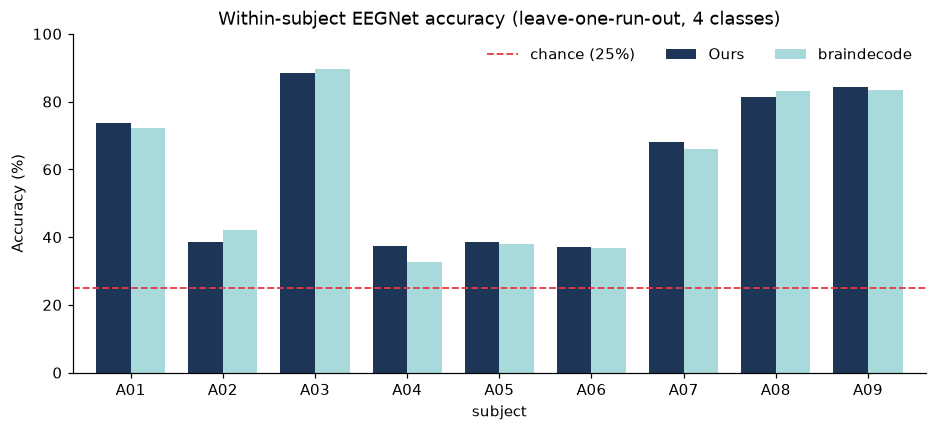

Mean accuracy: ours 60.8% ± 22.5%, braindecode 60.4% ± 23.0%
Per-subject difference (ours - braindecode): mean +0.5 pp, range -3.5 to +4.9 pp
Correlation of per-subject accuracies between the two implementations: 0.99


In [9]:
acc = within.pivot(index="subject", columns="model", values="accuracy")[["Ours", "braindecode"]]
ax = (acc * 100).plot.bar(figsize=(10, 4), color=["#1d3557", "#a8dadc"], rot=0, width=0.75)
ax.axhline(25, color="#e63946", ls="--", lw=1.2, label="chance (25%)")
ax.set_ylabel("Accuracy (%)"); ax.set_ylim(0, 100)
ax.set_title("Within-subject EEGNet accuracy (leave-one-run-out, 4 classes)")
ax.legend(frameon=False, ncol=3)
ax.figure.savefig(FIG_DIR / "03_within_subject_ours_vs_braindecode.png", bbox_inches="tight")
plt.show()

diff = (acc["Ours"] - acc["braindecode"]) * 100
print(f"Mean accuracy: ours {acc['Ours'].mean():.1%} ± {acc['Ours'].std():.1%}, "
      f"braindecode {acc['braindecode'].mean():.1%} ± {acc['braindecode'].std():.1%}")
print(f"Per-subject difference (ours - braindecode): mean {diff.mean():+.1f} pp, range {diff.min():+.1f} to {diff.max():+.1f} pp")
print(f"Correlation of per-subject accuracies between the two implementations: {np.corrcoef(acc['Ours'], acc['braindecode'])[0, 1]:.2f}")

**Why the two numbers are not exactly identical:** the forward computation is proven identical (check 2b). The small differences come from (1) different random weight initialisation (braindecode uses Xavier initialisation for the spatial layer), and (2) how the max-norm constraint is enforced: we project weights after each update, as in the original Keras code, while braindecode re-parametrises the weights. Both are valid EEGNet training. What matters is that the per-subject results agree closely.

### Per-subject details (our EEGNet, within-subject)

**Training curves.** Each panel shows one subject's 6 cross-validation folds: training in blue, validation in orange. The dot marks the epoch whose weights were kept (lowest validation loss). Training loss falling while validation loss rises is overfitting, and early stopping protects against it.

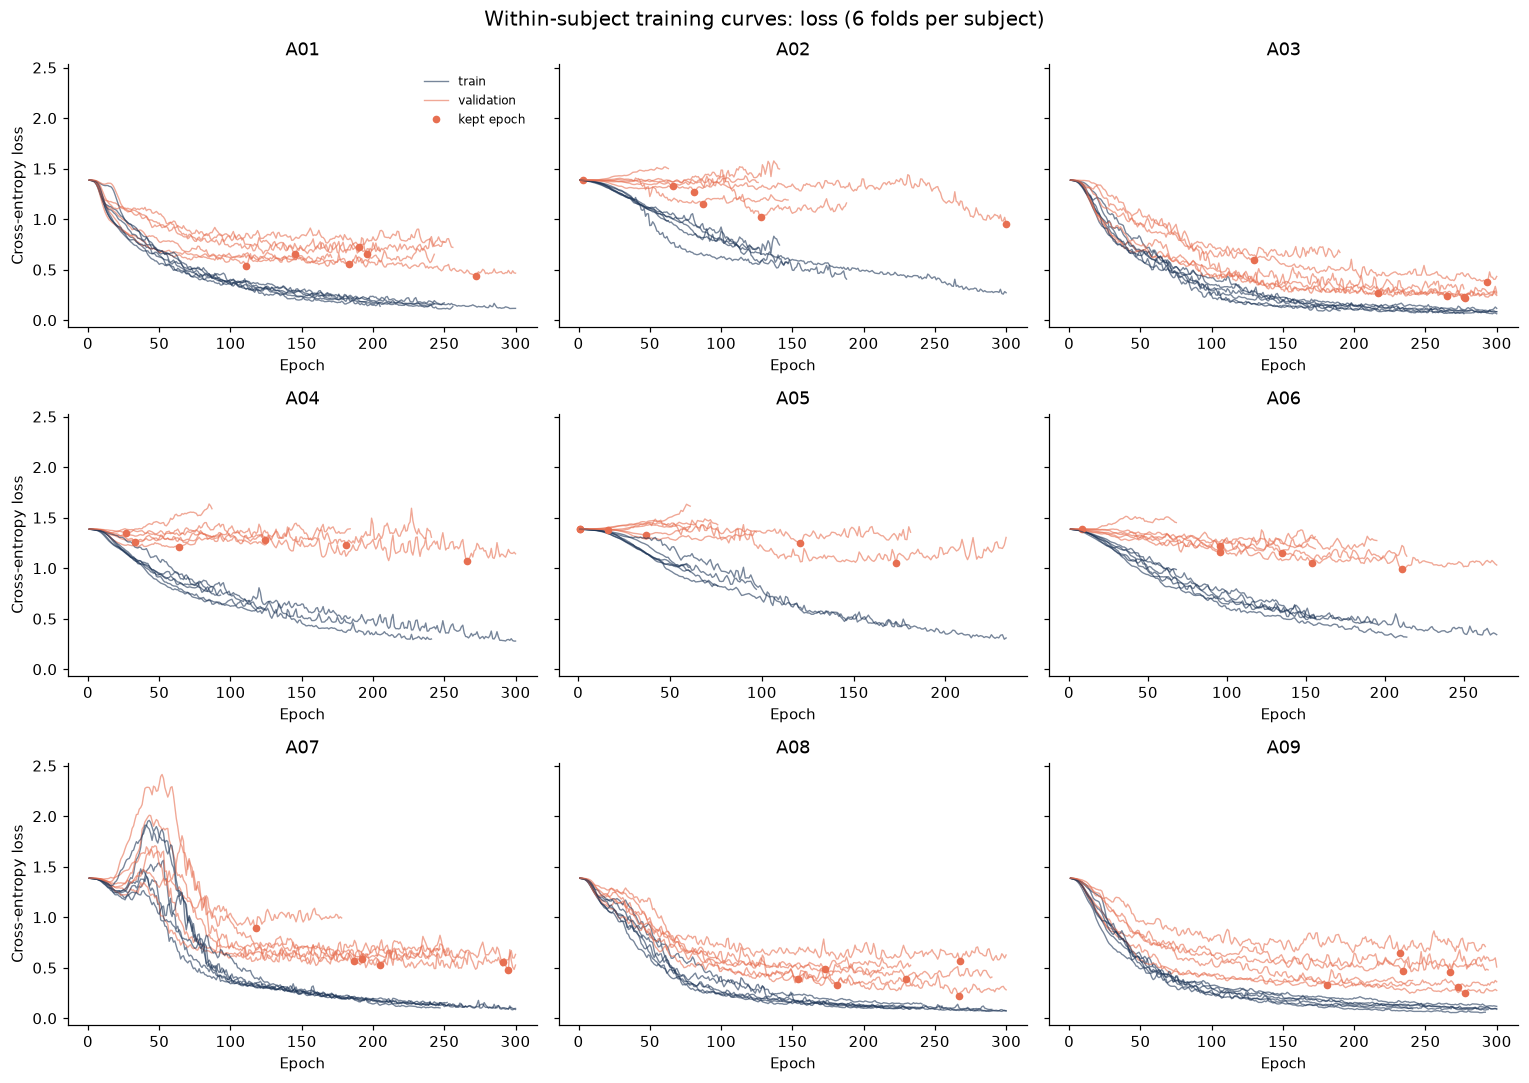

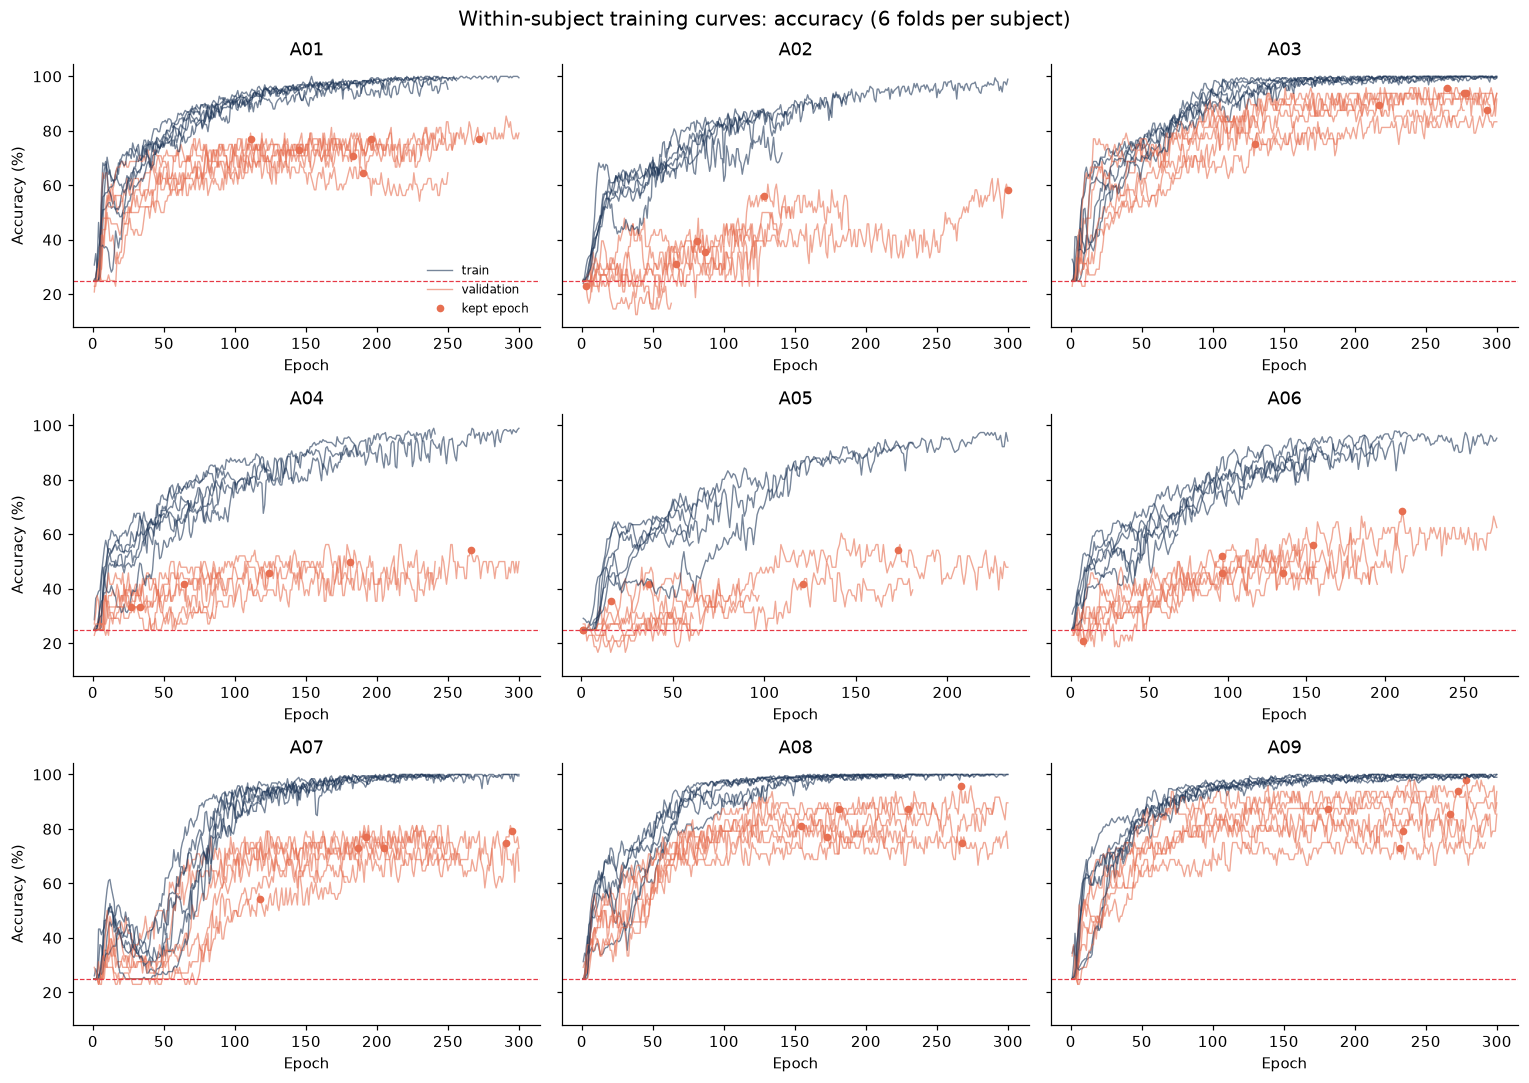

In [10]:
plot_curves_grid(within_hist, "loss", "Within-subject training curves: loss (6 folds per subject)",
                 FIG_DIR / "03_within_curves_loss_all_subjects.png")
plt.show()
plot_curves_grid(within_hist, "acc", "Within-subject training curves: accuracy (6 folds per subject)",
                 FIG_DIR / "03_within_curves_accuracy_all_subjects.png")
plt.show()

**Confusion matrices.** Each subject's 288 trials are tested once across the 6 folds. Rows are the true class and columns the predicted class; the diagonal is correct.

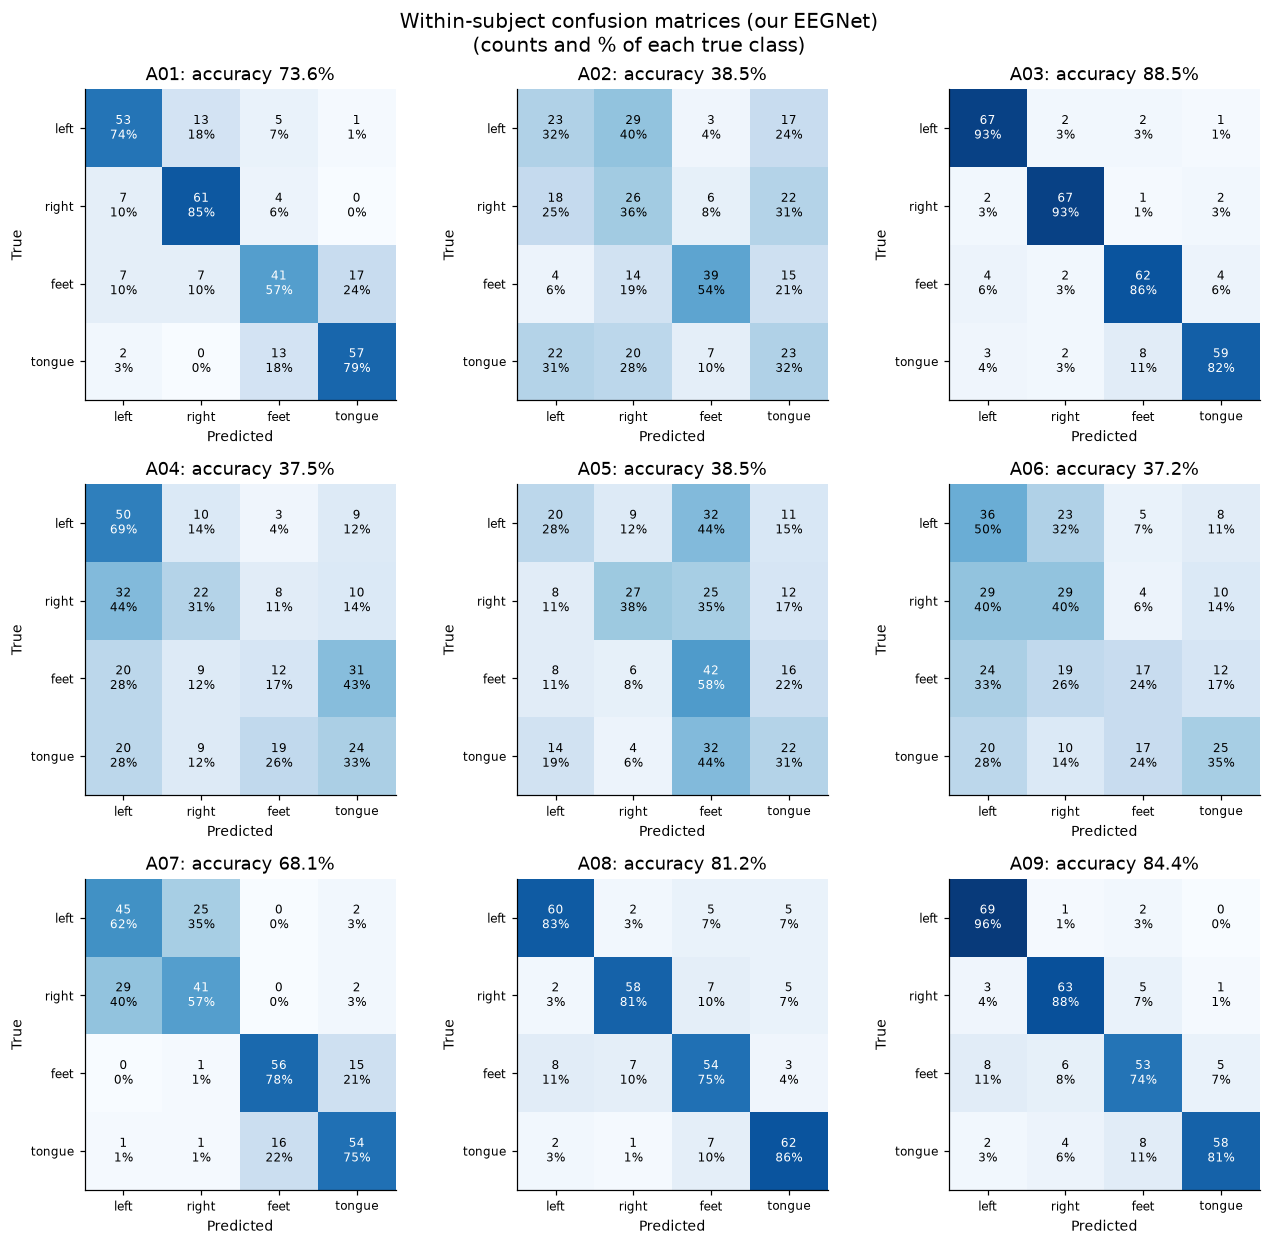

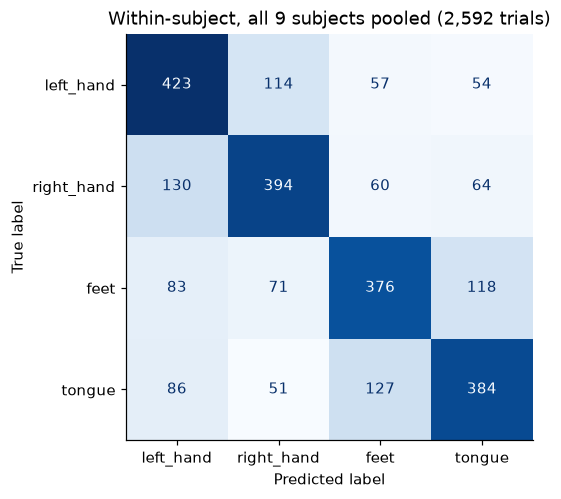

In [11]:
y_true_by_subj = {s: data[s][1] for s in SUBJECTS}
within_pred_ours = {s: preds[(s, "Ours")] for s in SUBJECTS}
plot_confusion_grid(y_true_by_subj, within_pred_ours, CLASS_NAMES,
                    "Within-subject confusion matrices (our EEGNet)", "Blues",
                    FIG_DIR / "03_within_confusion_all_subjects.png")
plt.show()

y_all = np.concatenate([data[s][1] for s in SUBJECTS])
fig, ax = plt.subplots(figsize=(5.5, 4.8))
ConfusionMatrixDisplay(confusion_matrix(y_all, np.concatenate([within_pred_ours[s] for s in SUBJECTS])),
                       display_labels=CLASS_NAMES).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Within-subject, all 9 subjects pooled (2,592 trials)")
fig.savefig(FIG_DIR / "03_within_confusion_pooled.png", bbox_inches="tight")
plt.show()

**Per-class recall:** the percentage of each class's trials that were classified correctly, per subject. This shows which motor-imagery classes (and therefore which wheelchair commands) are easiest or hardest to decode.

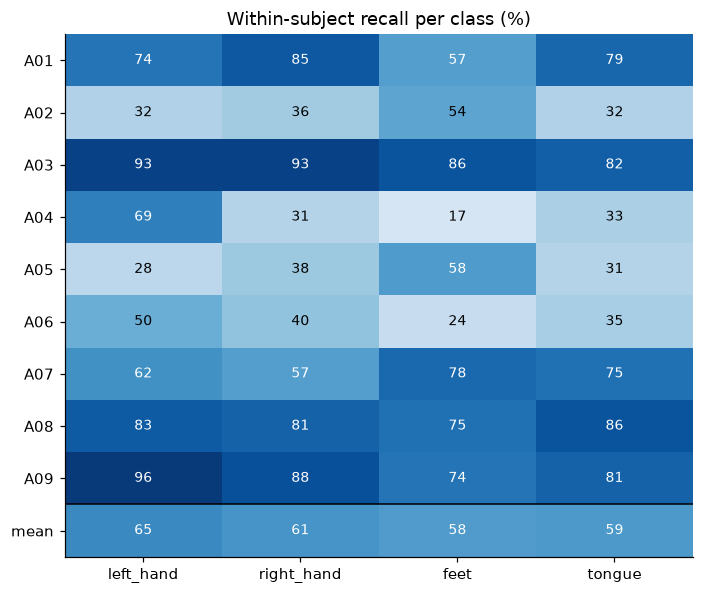

,left_hand,right_hand,feet,tongue
A01,73.6,84.7,56.9,79.2
A02,31.9,36.1,54.2,31.9
A03,93.1,93.1,86.1,81.9
A04,69.4,30.6,16.7,33.3
A05,27.8,37.5,58.3,30.6
A06,50.0,40.3,23.6,34.7
A07,62.5,56.9,77.8,75.0
A08,83.3,80.6,75.0,86.1
A09,95.8,87.5,73.6,80.6
mean,65.3,60.8,58.0,59.3


In [12]:
within_recall = per_class_recall(y_true_by_subj, within_pred_ours, CLASS_NAMES)
plot_recall_heatmap(within_recall, "Within-subject recall per class (%)", "Blues",
                    FIG_DIR / "03_within_recall_per_class.png")
plt.show()
within_recall

## 5. Preliminary cross-subject results: leave-one-subject-out (LOSO)

This is the **actual setting of our project**: the model never sees the test person during training.
- For each of 9 folds: **test = 1 subject (all 288 trials)**, **train = the other 8 subjects**.
- 20% of the 8 training subjects' trials (stratified by subject and class) are held out for early stopping, following Junqueira et al. (2024).
- Scaler fitted on training trials only. **No alignment yet**: this is the *no-EA baseline* that EA will later be compared against.
- Dropout 0.25 (paper's cross-subject setting), batch size 64, up to 200 epochs, patience 40.

In [13]:
loso_rows, loso_pred, loso_hist = [], {}, {}
t0 = time.time()
for target in SUBJECTS:
    sources = [s for s in SUBJECTS if s != target]
    X_src = np.concatenate([data[s][0] for s in sources])
    y_src = np.concatenate([data[s][1] for s in sources])
    subj_src = np.repeat(np.arange(len(sources)), 288)
    tr_idx, va_idx = train_test_split(np.arange(len(y_src)), test_size=0.2, random_state=0,
                                      stratify=subj_src * 4 + y_src)
    X_te, y_te = data[target]
    scaler = ChannelScaler().fit(X_src[tr_idx])
    set_seed(0)
    model, hist = train_model(EEGNet(dropout=0.25), scaler.transform(X_src[tr_idx]), y_src[tr_idx],
                              scaler.transform(X_src[va_idx]), y_src[va_idx],
                              lr=1e-3, batch_size=64, max_epochs=200, patience=40, seed=0)
    loso_pred[target] = predict_logits(model, scaler.transform(X_te)).argmax(1)
    loso_hist[target] = [hist]
    loso_rows.append({"subject": target, **classification_metrics(y_te, loso_pred[target]),
                      "best_epoch": hist["best_epoch"] + 1})
    print(f"target {target}: accuracy {loso_rows[-1]['accuracy']:.1%}  ({time.time() - t0:.0f} s)")

loso = pd.DataFrame(loso_rows)
loso.to_csv(RESULTS / "eegnet_loso_no_ea.csv", index=False)
summary_loso = loso.set_index("subject")[["accuracy", "kappa", "macro_f1"]].round(3)
summary_loso.loc["mean"] = summary_loso.mean().round(3)
summary_loso.loc["std"] = summary_loso.iloc[:-1].std().round(3)
summary_loso

target A01: accuracy 62.2%  (168 s)


target A02: accuracy 30.2%  (291 s)


target A03: accuracy 53.8%  (459 s)


target A04: accuracy 38.2%  (627 s)


target A05: accuracy 26.0%  (795 s)


target A06: accuracy 29.2%  (962 s)


target A07: accuracy 30.6%  (1129 s)


target A08: accuracy 64.6%  (1296 s)


target A09: accuracy 58.0%  (1462 s)


,accuracy,kappa,macro_f1
subject,,,
A01,0.622,0.495,0.614
A02,0.302,0.069,0.280
A03,0.538,0.384,0.500
A04,0.382,0.176,0.362
A05,0.260,0.014,0.134
A06,0.292,0.056,0.215
A07,0.306,0.074,0.284
A08,0.646,0.528,0.639
A09,0.580,0.440,0.558


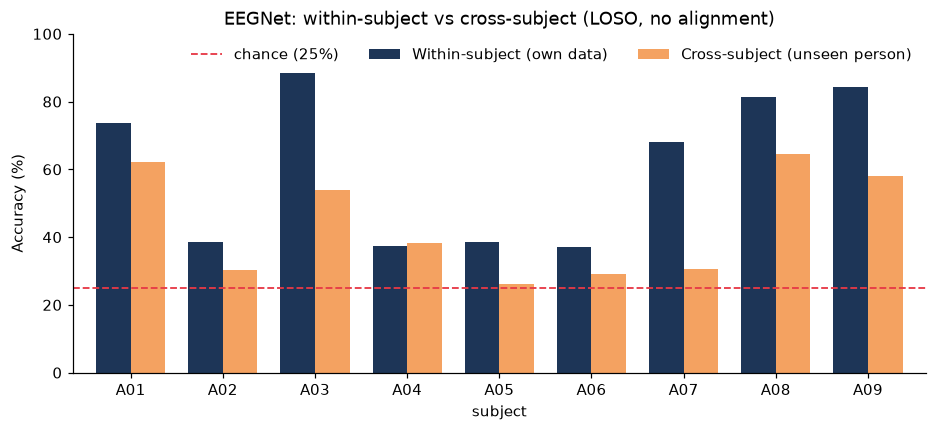

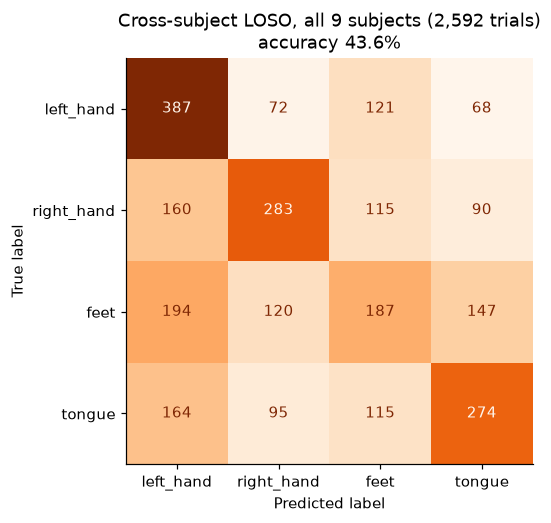

Mean within-subject accuracy: 60.8%   Mean cross-subject accuracy: 43.6%
Average drop when the person is unseen: 17.2 percentage points (largest: A07, 37.5 pp)


In [14]:
comp = pd.DataFrame({"Within-subject (own data)": acc["Ours"].values,
                     "Cross-subject (unseen person)": loso.set_index("subject").loc[acc.index, "accuracy"].values},
                    index=acc.index) * 100
ax = comp.plot.bar(figsize=(10, 4), color=["#1d3557", "#f4a261"], rot=0, width=0.75)
ax.axhline(25, color="#e63946", ls="--", lw=1.2, label="chance (25%)")
ax.set_ylabel("Accuracy (%)"); ax.set_ylim(0, 100)
ax.set_title("EEGNet: within-subject vs cross-subject (LOSO, no alignment)")
ax.legend(frameon=False, ncol=3)
ax.figure.savefig(FIG_DIR / "03_within_vs_cross_subject.png", bbox_inches="tight")
plt.show()

y_all = np.concatenate([data[s][1] for s in SUBJECTS]); p_all = np.concatenate([loso_pred[s] for s in SUBJECTS])
fig, ax = plt.subplots(figsize=(5.5, 4.8))
ConfusionMatrixDisplay(confusion_matrix(y_all, p_all), display_labels=CLASS_NAMES).plot(ax=ax, cmap="Oranges", colorbar=False)
ax.set_title(f"Cross-subject LOSO, all 9 subjects (2,592 trials)\naccuracy {(y_all == p_all).mean():.1%}")
fig.savefig(FIG_DIR / "03_loso_confusion_matrix.png", bbox_inches="tight")
plt.show()

gap = comp.iloc[:, 0] - comp.iloc[:, 1]
print(f"Mean within-subject accuracy: {comp.iloc[:, 0].mean():.1f}%   Mean cross-subject accuracy: {comp.iloc[:, 1].mean():.1f}%")
print(f"Average drop when the person is unseen: {gap.mean():.1f} percentage points (largest: {gap.idxmax()}, {gap.max():.1f} pp)")

### Per-subject details (cross-subject LOSO)

**Training curves.** One model per held-out subject, trained on the other 8. The validation data here comes from the **training subjects**, not from the held-out person, so good validation accuracy does not guarantee good accuracy on the new person. That gap is exactly the cross-subject problem.

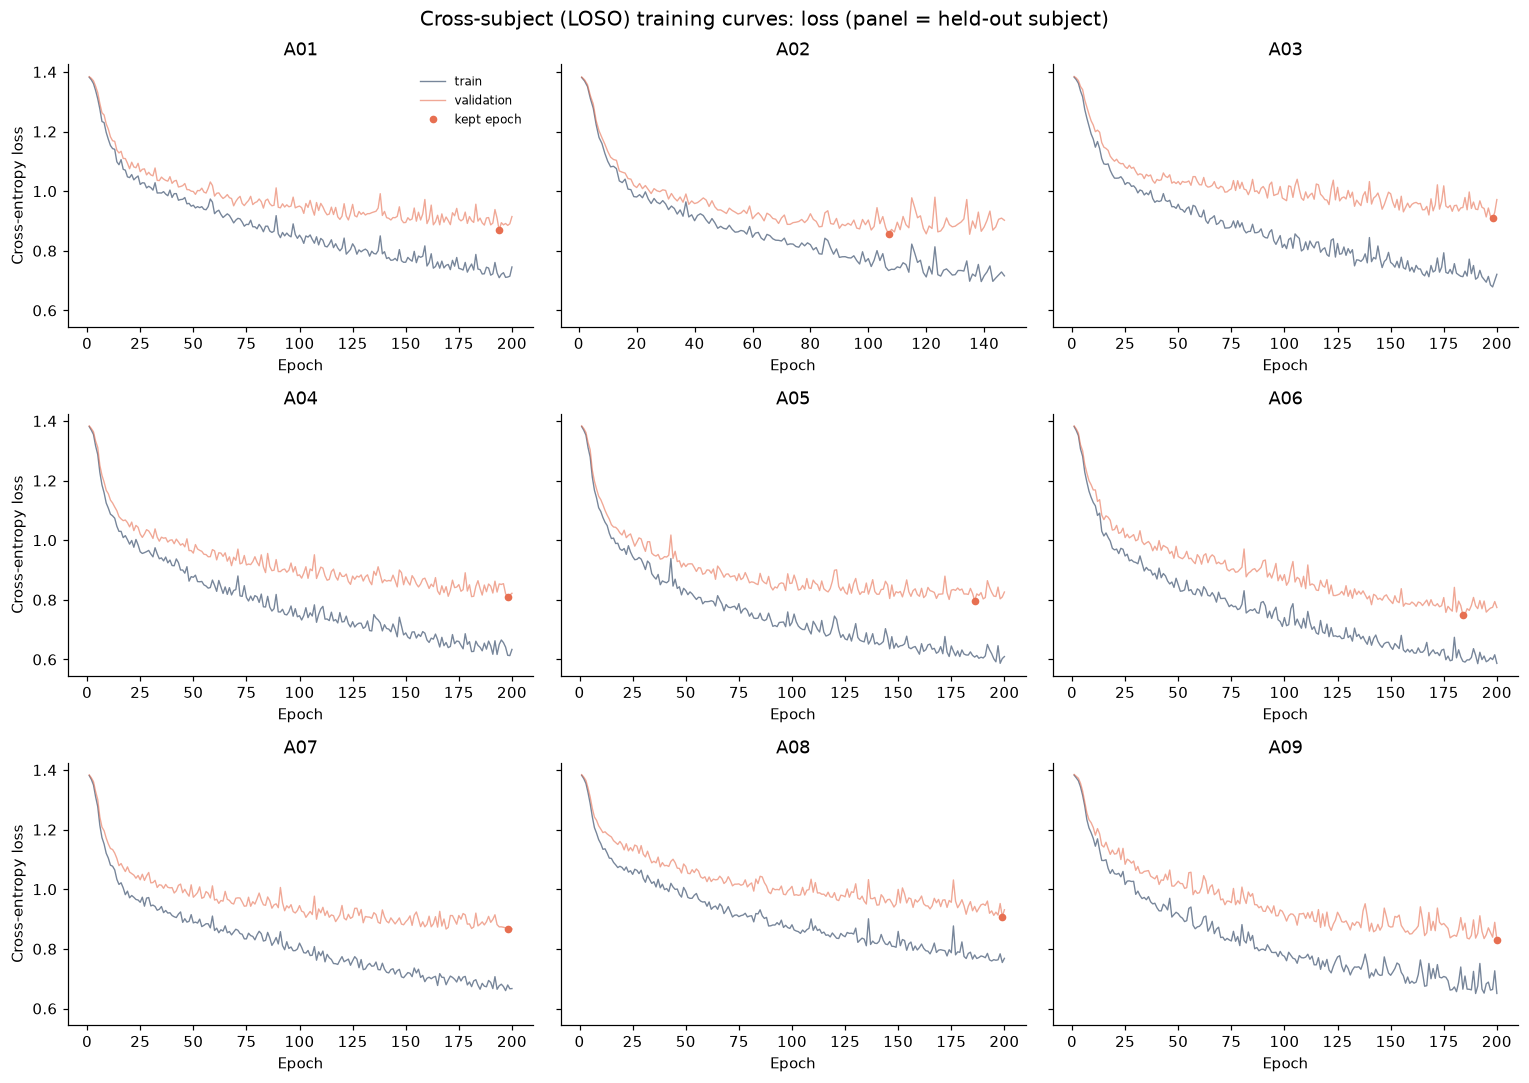

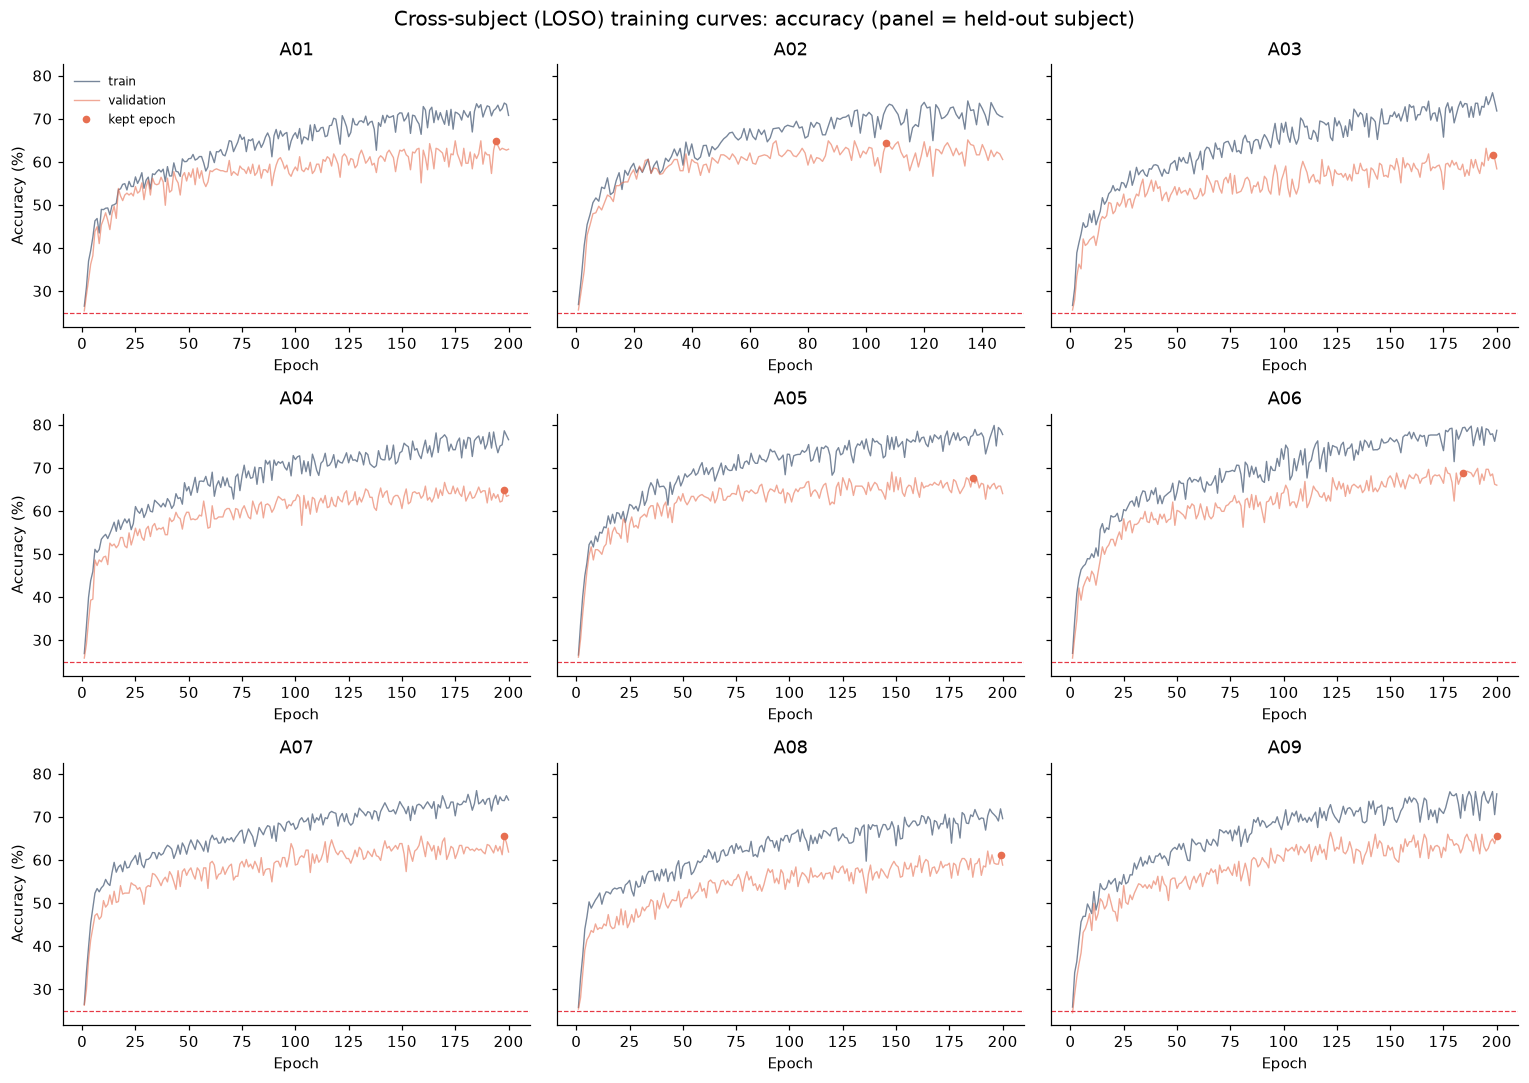

In [15]:
plot_curves_grid(loso_hist, "loss", "Cross-subject (LOSO) training curves: loss (panel = held-out subject)",
                 FIG_DIR / "03_loso_curves_loss_all_subjects.png")
plt.show()
plot_curves_grid(loso_hist, "acc", "Cross-subject (LOSO) training curves: accuracy (panel = held-out subject)",
                 FIG_DIR / "03_loso_curves_accuracy_all_subjects.png")
plt.show()

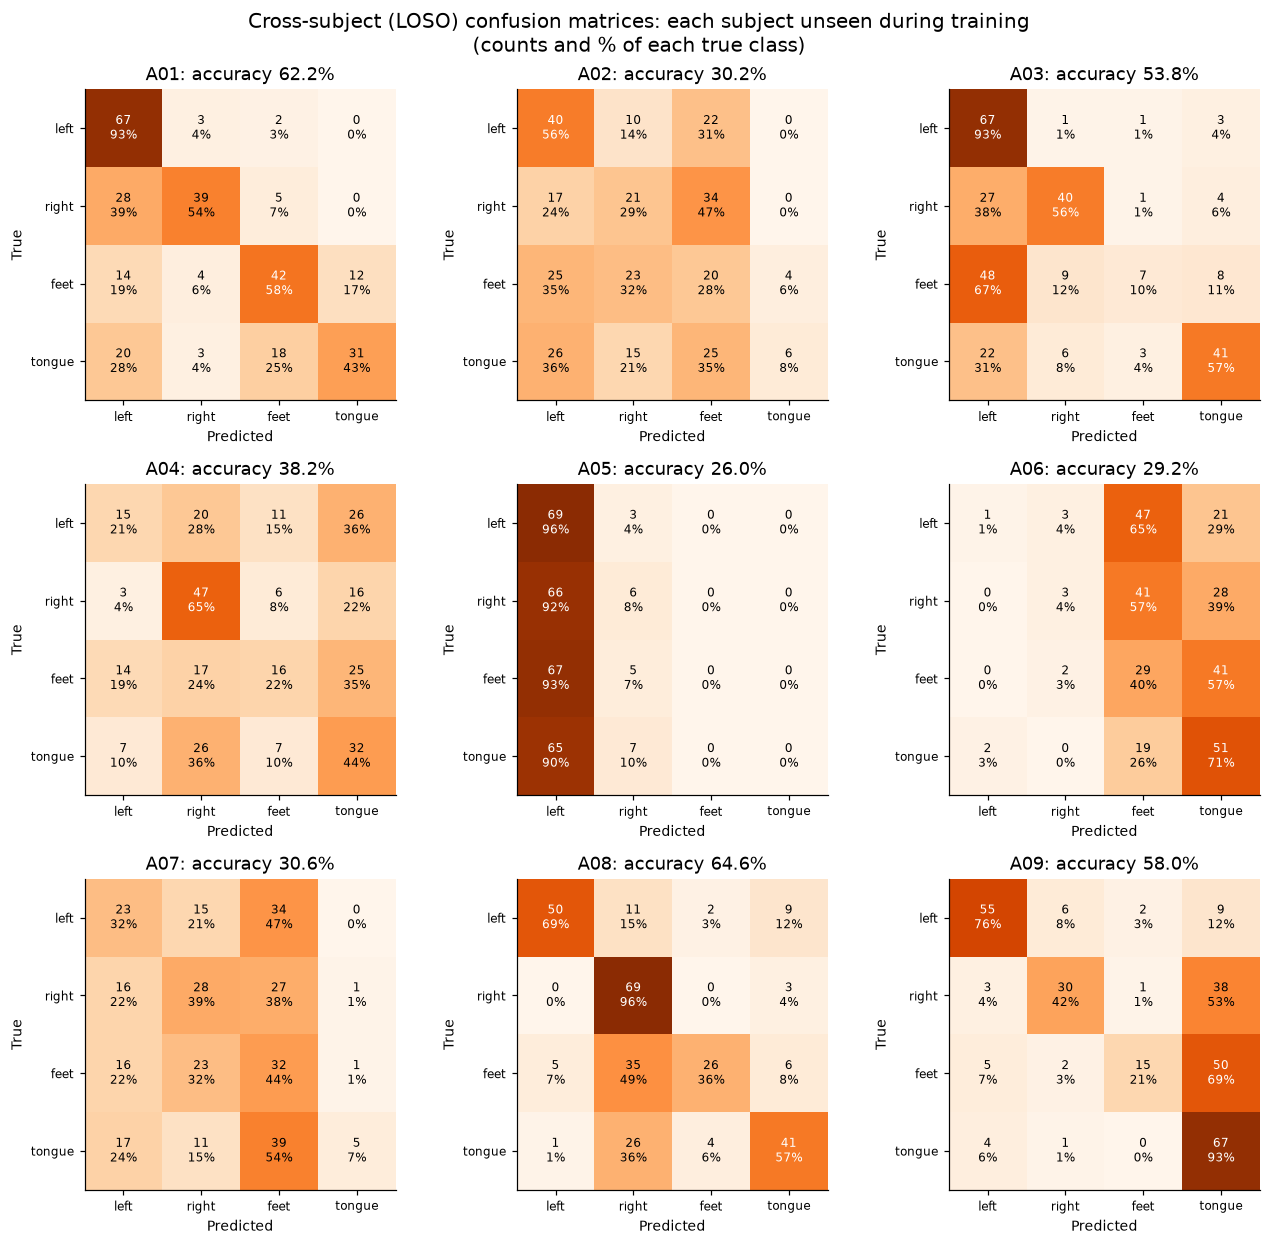

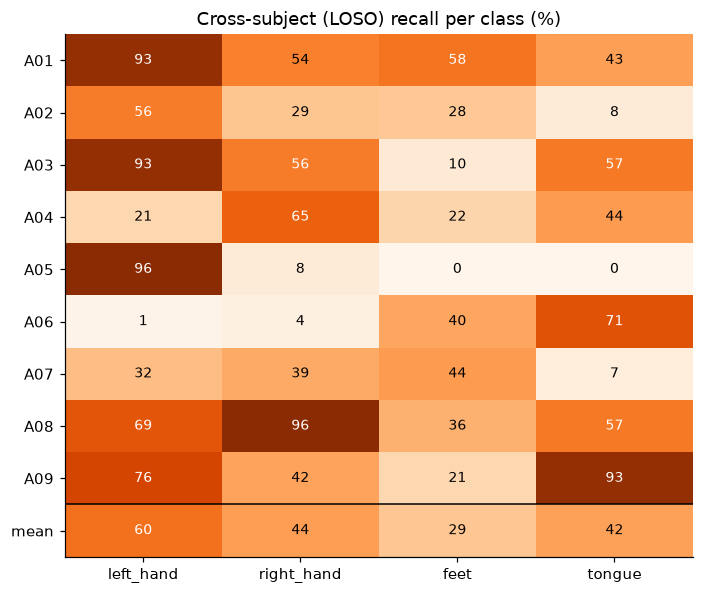

,left_hand,right_hand,feet,tongue
A01,93.1,54.2,58.3,43.1
A02,55.6,29.2,27.8,8.3
A03,93.1,55.6,9.7,56.9
A04,20.8,65.3,22.2,44.4
A05,95.8,8.3,0.0,0.0
A06,1.4,4.2,40.3,70.8
A07,31.9,38.9,44.4,6.9
A08,69.4,95.8,36.1,56.9
A09,76.4,41.7,20.8,93.1
mean,59.7,43.7,28.9,42.3


In [16]:
plot_confusion_grid(y_true_by_subj, loso_pred, CLASS_NAMES,
                    "Cross-subject (LOSO) confusion matrices: each subject unseen during training", "Oranges",
                    FIG_DIR / "03_loso_confusion_all_subjects.png")
plt.show()

loso_recall = per_class_recall(y_true_by_subj, loso_pred, CLASS_NAMES)
plot_recall_heatmap(loso_recall, "Cross-subject (LOSO) recall per class (%)", "Oranges",
                    FIG_DIR / "03_loso_recall_per_class.png")
plt.show()
loso_recall

### Save all predictions
Per-trial predictions are saved so later steps (calibration, entropy, rejection) and any re-plotting can reuse them without retraining.

In [17]:
pred_table = pd.concat([pd.DataFrame({"subject": s, "trial": np.arange(288), "run": RUN,
                                      "true": data[s][1],
                                      "within_ours": preds[(s, "Ours")],
                                      "within_braindecode": preds[(s, "braindecode")],
                                      "loso_no_ea": loso_pred[s]}) for s in SUBJECTS])
pred_table.to_csv(RESULTS / "eegnet_predictions.csv", index=False)
print(f"Saved {len(pred_table)} rows to results/eegnet_predictions.csv")
print("Result files:", sorted(p.name for p in RESULTS.glob("*.csv")))

Saved 2592 rows to results/eegnet_predictions.csv
Result files: ['dataset_summary.csv', 'eegnet_loso_no_ea.csv', 'eegnet_predictions.csv', 'eegnet_within_subject.csv']


## 6. Summary

### Implementation is verified
| Check | Result |
|---|---|
| Architecture vs braindecode | all 8 layers identical, **4,172 parameters** in both |
| Numerical equivalence (same weights, same input) | max output difference **0.0**, same predicted class for all inputs |
| Max-norm constraints | enforced exactly (1.0 spatial, 0.25 dense) |
| Can it learn? (overfit 32 trials) | training accuracy **100%**, loss 1.375 → 0.010 |
| Same training, both implementations | mean accuracy **60.8% vs 60.4%**, per-subject correlation **0.99** |

### Within-subject baseline (leave-one-run-out on the `T` session)
- **Mean accuracy 60.8% ± 22.5%** (kappa 0.48), against a chance level of 25%.
- Strong subjects: **A03 88.5%, A09 84.4%, A08 81.2%, A01 73.6%, A07 68.1%**.
- Weak subjects: **A02, A04, A05, A06 at about 37–39%**. Their validation loss barely decreases, so with only 192 training trials the model finds little that generalises for them.
- Not directly comparable to published within-subject results, which usually train on the full `T` session (288 trials) and test on the `E` session. We train on 4 runs (192 trials) because the `E` labels are not available yet.

### Cross-subject baseline (LOSO, no alignment): the core problem of our project
- **Mean accuracy 43.6% ± 15.8%** (kappa 0.25, macro-F1 0.40): **17.2 percentage points lower** than within-subject.
- The drop is uneven. A07 falls from 68.1% to 30.6%, while A04 stays about the same.
- **Several unseen subjects collapse onto one or two classes**:
  - A05: about 93% of all trials are predicted *left hand* (26.0%, chance level).
  - A06: *left* and *right hand* are almost never predicted.
  - A02 and A07: *tongue* is almost never predicted.

  In a wheelchair, this means the same command would be issued no matter what the user imagines. It is the clearest motivation for both parts of our project: **alignment** (to make a new person's EEG look like the training data) and **rejection** (so these unreliable predictions do not become commands).
- Validation accuracy on the training subjects (≈60–69%) is **much higher** than accuracy on the unseen person for most folds. Validation data from *other* people does not tell us how well the model will work for a *new* person. This matters later when choosing the temperature and entropy threshold.

### Limitations of this first baseline
- Only the `T` sessions are used (the `E` labels are still missing).
- One random seed, and no hyperparameter tuning.
- 8 of 9 LOSO models kept an epoch close to the 200-epoch limit, so they may still have been improving. A longer training budget should be tried.

### Next steps
1. **Euclidean Alignment**: add EA before EEGNet and compare against this LOSO no-EA baseline (`results/eegnet_loso_no_ea.csv`).
2. **Temperature scaling, predictive entropy and the reject option** on the LOSO predictions: risk, coverage and false actionable commands.
3. Obtain the `E`-session labels to use both sessions.